# Homework I

### Metriche
* PSNR: più alto è meglio.
* SSIM: più vicino a 1 è meglio.
* RE: errore relativo, più basso è meglio.

## Denoise - TV

In [ ]:
import sys
import os

import torch
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Add the parent directory of 'examples/' to sys.path
#sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
project_dir = Path("/content/drive/MyDrive/Colab Notebooks/Esame CI/HomeworkI")
sys.path.append(str(project_dir))

from IPPy import utilities, operators, solvers
from IPPy.utilities import load_image, save_image, normalize
from IPPy.utilities.metrics import PSNR, SSIM, RE

# Set device
device = utilities.get_device()
print(f"Device used: {device}.")

# Load GT image
#x_true = load_image("../data/Mayo/test/C081/0.png")
#script_dir = Path(_file_).resolve().parent
#img_path = script_dir / "0.png"
img_path = project_dir / "Code" / "0.png"
print((img_path))
x_true = load_image(str(img_path))
print(f"Shape of the GT: {list(x_true.shape)}.")

# Create the identity operator - GT
K = operators.Identity(
    img_shape=x_true.shape[-2:],
)

# Build test problem
noise_level = 0.05
y_delta = K(x_true) + noise_level * torch.randn_like(x_true) # y_delta = img. originale + rumore
print(f"Shape of the measurements: {list(y_delta.shape)}.")

# Save the results
save_image(normalize(x_true), "gt_image.png")
save_image(normalize(y_delta), "noised_image.png")


# Set up the solver: TV
lambda_tv = 5e-4
maxiter = 200
tolf = tolx = 1e-6
solver = solvers.ChambollePockTpVUnconstrained(K)

# Run the solver
x_sol, info = solver(
    y_delta,
    x_true=x_true,
    starting_point=torch.zeros_like(x_true),
    lmbda=lambda_tv,
    maxiter=maxiter,
    tolf=tolf,
    tolx=tolx,
    p=1.0, # Con p = 1, la Total-p Variation diventa sostanzialmente TV classica
    verbose=True,
)

# Compute metrics
psnr = PSNR(x_sol, x_true)
ssim = SSIM(x_sol, x_true)
re = RE(x_sol, x_true)
print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f} | RE: {re:.4f}")

# Save the results
#save_image(normalize(x_true), "gt_image.png")
#save_image(normalize(y_delta), "noised_image.png")
save_image(normalize(x_sol), "denoised_imageTV.png")

## Deblur - Tikhonov & TpV

In [ ]:
import sys
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add the parent directory of 'examples/' to sys.path
project_dir = Path("/content/drive/MyDrive/Colab Notebooks/Esame CI/HomeworkI")
sys.path.append(str(project_dir))

from IPPy import utilities, operators, solvers
from IPPy.utilities import load_image, save_image, normalize
from IPPy.utilities.metrics import PSNR, SSIM, RE

# Set device
device = utilities.get_device()
print(f"Device used: {device}.")

# Load GT image
#x_true = load_image("../data/Mayo/test/C081/0.png")
img_path = project_dir / "Code" / "0.png"
x_true = load_image(str(img_path))
print(f"Shape of the GT: {list(x_true.shape)}.")

# Create the blurring operator
kernel_size = 11
sigma = 1.5
K = operators.Blurring(
    img_shape=x_true.shape[-2:],
    kernel_type="gaussian",
    kernel_size=kernel_size,
    kernel_variance=sigma**2,
)

# Build test problem
noise_level = 0.01
y_delta = K(x_true)  + noise_level * torch.randn_like(x_true)
print(f"Shape of the measurements: {list(y_delta.shape)}.")

# Set up the solver: Tikhonov
lambda_tik=0.1
maxiter=100
tolf=tolx=1.e-7
solver = solvers.CGLS(K)


x_sol, info = solver(
    y_delta,
    x_true=x_true,
    starting_point=torch.zeros_like(x_true),
    lam=lambda_tik,
    maxiter=maxiter,
    tolf=tolf,
    tolx=tolx,
    verbose=True,
)
print(info.keys())

""" plt.figure()
plt.plot(info["SSIM"],'o')
plt.xlabel("iterations")
plt.ylabel("SSIM")
plt.show() """

# Compute metrics
psnr = PSNR(x_sol, x_true)
ssim = SSIM(x_sol, x_true)
re = RE(x_sol, x_true)
print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f} | RE: {re:.4f}")

save_image(normalize(x_true), "gt_image.png")
save_image(normalize(y_delta), "blurred_image.png")
save_image(normalize(x_sol), "deblurred_image_tik.png")

# Set up the solver
lambda_tv = 1e-2
max_iters = 100
solver = solvers.ChambollePockTpVUnconstrained(K)

# Run the solver
x_sol, info = solver(
    y_delta,
    x_true=x_true,
    starting_point=torch.ones_like(x_true),
    lmbda=lambda_tv,
    max_iters=max_iters,
    p=0.5,
    verbose=True,
)

# Compute metrics
psnr = PSNR(x_sol, x_true)
ssim = SSIM(x_sol, x_true)
re = RE(x_sol, x_true)
print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f} | RE: {re:.4f}")

# Save the results
save_image(normalize(x_sol), "deblurred_image_tpv.png")

## Super resolution - TV

In [ ]:
import sys
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add the parent directory of 'examples/' to sys.path
project_dir = Path("/content/drive/MyDrive/Colab Notebooks/Esame CI/HomeworkI")
sys.path.append(str(project_dir))

from IPPy import utilities, operators, solvers
from IPPy.utilities import load_image, save_image, normalize
from IPPy.utilities.metrics import PSNR, SSIM, RE

# Set device
device = utilities.get_device()
print(f"Device used: {device}.")

# Load GT image
img_path = project_dir / "Code" / "0.png"
x_true = load_image(str(img_path))
#x_true = load_image("../data/Mayo/test/C081/0.png")
print(f"Shape of the GT: {list(x_true.shape)}.")

# Create the downscaling operator

K = operators.DownScaling(
    img_shape=x_true.shape[-2:],
    downscale_factor=2,
    mode='avg',
)

# Build test problem
noise_level = 0.01
y=K(x_true)
y_delta = y + noise_level * torch.randn_like(y)
print(f"Shape of the measurements: {list(y_delta.shape)}.")

""" print(info.keys())

plt.figure()
plt.plot(info["SSIM"])
plt.xlabel("iterations")
plt.ylabel("SSIM")
plt.show()

# Compute metrics
psnr = PSNR(x_sol, x_true)
ssim = SSIM(x_sol, x_true)
re = RE(x_sol, x_true)
print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f} | RE: {re:.4f}")
"""
save_image(normalize(x_true), "gt_image.png")
save_image(normalize(y_delta), "DR_image.png")
#save_image(normalize(x_sol), "deblurred_image_tik.png")

# Set up the solver
lambda_tv = 1e-1
max_iters = 100
solver = solvers.ChambollePockTpVUnconstrained(K)

# Run the solver
x_sol, info = solver(
    y_delta,
    x_true=x_true,
    starting_point=torch.zeros_like(x_true),
    lmbda=lambda_tv,
    max_iters=max_iters,
    p=1.0,
    verbose=True,
)

# Compute metrics
psnr = PSNR(x_sol, x_true)
ssim = SSIM(x_sol, x_true)
re = RE(x_sol, x_true)
print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f} | RE: {re:.4f}")

# Save the results
save_image(normalize(x_sol), "SR_image_tv.png")

## CT image reconstruction  - FBP & TV

In [ ]:
!pip install astra-toolbox
# Su Colab, eseguire il comando e poi riavviare la sessione (Runtime -> Riavvia sessione)

In [ ]:
import os
import sys
import time

import numpy as np
import torch

from pathlib import Path

# Add the parent directory of 'examples/' to sys.path
project_dir = Path("/content/drive/MyDrive/Colab Notebooks/Esame CI/HomeworkI")
sys.path.append(str(project_dir))

from IPPy import operators, utilities, solvers
from IPPy.utilities import data, metrics
from IPPy.utilities import load_image, save_image, normalize
from IPPy.utilities.metrics import PSNR, SSIM, RE


#################################################
### SETTING THINGS UP
#################################################

# Set a seed (for reproducibility)
torch.manual_seed(0)

# Set required parameters
# Load GT image
#x_true = load_image("../data/Mayo/test/C081/0.png")
img_path = project_dir / "Code" / "0.png"
x_true = load_image(str(img_path))

start_angle = 0  # first angle of angular range
end_angle = 180  # last angle of angular range
n_angles = 180  # number of projections
det_size = 512  # detector resolution

#geometry = "fanflat"  # This is the only one available right now
noise_level = 0.000

lmbda = 0.01  # The regularization parameter for the algorithm
maxiter = 100  # Number of maximum iterations for the solver
p = 1  # Sparsity parameter (only for ChambollePock solver)

# Define CTOperator
#angles = np.linspace(np.deg2rad(start_angle), np.deg2rad(end_angle), n_angles)
K = operators.CTProjector(
    img_shape=(512,512),
    angles=np.linspace(0, np.pi, 60),
    det_size=512,
    geometry="parallel",
)

""" K = operators.CTProjector(
    img_shape=(512,512),
    angles=angles,
    geometry=geometry,
    source_origin=2800,
    origin_det=500,
)
 """

# Compute noisy sinogram
y = K(x_true)  # Forward projection
y_delta = y + utilities.gaussian_noise(y, noise_level=noise_level)

solver1=solvers.FBP(K)

# SOLUTION
x_sol,info = solver1(
    y_delta,
    x_true=x_true,
    starting_point=y_delta,
)



    # METRICS

    # Compute metrics
psnr = PSNR(x_sol, x_true)
ssim = SSIM(x_sol, x_true)
re = RE(x_sol, x_true)
print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f} | RE: {re:.4f}")


save_image(normalize(x_true), "gt_image.png")
save_image(y_delta, "sinogram.png")
save_image(normalize(x_sol), "FBP.png")

# Initialize solver
solver = solvers.ChambollePockTpVUnconstrained(K)

#################################################
### EXECUTION
#################################################


# SOLUTION
x_sol, info = solver(
    y_delta,
    lmbda=lmbda,
    starting_point=None,
    x_true=x_true,
    maxiter=maxiter,
    p=p,
    verbose=True,
)

    # METRICS
print(
    f"RE = {metrics.RE(x_sol, x_true):0.4f}, ",
    f"PSNR = {metrics.PSNR(x_sol, x_true):0.4f}, SSIM = {metrics.SSIM(x_sol, x_true):0.4f}.",
)
save_image(normalize(x_sol), "reconstruction_TV.png")


## Homework completo

#### Setting

In [ ]:
import sys
import os

import torch
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Add the parent directory of 'examples/' to sys.path
#sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
project_dir = Path("/content/drive/MyDrive/Colab Notebooks/Esame CI/HomeworkI")
sys.path.append(str(project_dir))

from IPPy import utilities, operators, solvers
from IPPy.utilities import load_image, save_image, normalize
from IPPy.utilities.metrics import PSNR, SSIM, RE

# Set device
device = utilities.get_device()
print(f"Device used: {device}.")

# Load GT image
#x_true = load_image("../data/Mayo/test/C081/0.png")
#script_dir = Path(_file_).resolve().parent
#img_path = script_dir / "0.png"
img_path = project_dir / "Code" / "0.png"
print((img_path))
x_true = load_image(str(img_path))
print(f"Shape of the GT: {list(x_true.shape)}.")
save_image(normalize(x_true), "gt_image.png")

#### Problem

##### Noise

In [ ]:
# Create the identity operator - GT
K = operators.Identity(
    img_shape=x_true.shape[-2:],
)

# Build test problem
noise_level = 0.05
y_delta = K(x_true) + noise_level * torch.randn_like(x_true) # y_delta = img. originale + rumore
print(f"Shape of the measurements: {list(y_delta.shape)}.")

# Save the results
save_image(normalize(y_delta), "noised_image.png")

##### Blur

In [ ]:
# Create the blurring operator
kernel_size = 11
sigma = 1.5
K = operators.Blurring(
    img_shape=x_true.shape[-2:],
    kernel_type="gaussian",
    kernel_size=kernel_size,
    kernel_variance=sigma**2,
)

# Build test problem
noise_level = 0.01
y_delta = K(x_true)  + noise_level * torch.randn_like(x_true)
print(f"Shape of the measurements: {list(y_delta.shape)}.")
save_image(normalize(y_delta), "blurred_image.png")

##### Super resolution

In [ ]:
# Create the downscaling operator

K = operators.DownScaling(
    img_shape=x_true.shape[-2:],
    downscale_factor=2,
    mode='avg',
)

# Build test problem
noise_level = 0.01
y=K(x_true)
y_delta = y + noise_level * torch.randn_like(y)
print(f"Shape of the measurements: {list(y_delta.shape)}.")

save_image(normalize(y_delta), "DR_image.png")

##### CT image reconstruction

In [ ]:
# Set a seed (for reproducibility)
torch.manual_seed(0)

start_angle = 0  # first angle of angular range
end_angle = 180  # last angle of angular range
n_angles = 180  # number of projections
det_size = 512  # detector resolution

#geometry = "fanflat"  # This is the only one available right now
noise_level = 0.000

lmbda = 0.01  # The regularization parameter for the algorithm
maxiter = 100  # Number of maximum iterations for the solver
p = 1  # Sparsity parameter (only for ChambollePock solver)

# Define CTOperator
#angles = np.linspace(np.deg2rad(start_angle), np.deg2rad(end_angle), n_angles)
K = operators.CTProjector(
    img_shape=(512,512),
    angles=np.linspace(0, np.pi, 60),
    det_size=512,
    geometry="parallel",
)

""" K = operators.CTProjector(
    img_shape=(512,512),
    angles=angles,
    geometry=geometry,
    source_origin=2800,
    origin_det=500,
)
 """

# Compute noisy sinogram
y = K(x_true)  # Forward projection
y_delta = y + utilities.gaussian_noise(y, noise_level=noise_level)

solver1=solvers.FBP(K)

# SOLUTION
x_sol,info = solver1(
    y_delta,
    x_true=x_true,
    starting_point=y_delta,
)

save_image(y_delta, "sinogram.png")
save_image(normalize(x_sol), "FBP.png")

#### Solver

##### Tikhonov

In [ ]:
# Set up the solver: Tikhonov
lambda_tik=0.1
maxiter=100
tolf=tolx=1.e-7
solver = solvers.CGLS(K)


x_sol, info = solver(
    y_delta,
    x_true=x_true,
    starting_point=torch.zeros_like(x_true),
    lam=lambda_tik,
    maxiter=maxiter,
    tolf=tolf,
    tolx=tolx,
    verbose=True,
)
print(info.keys())
save_image(normalize(x_sol), "SolvedImageTikhonov.png")

##### Total Variation (TV)

In [ ]:
# Set up the solver: TV
lambda_tv = 5e-4
maxiter = 200
tolf = tolx = 1e-6
solver = solvers.ChambollePockTpVUnconstrained(K)

# Run the solver
x_sol, info = solver(
    y_delta,
    x_true=x_true,
    starting_point=torch.zeros_like(x_true),
    lmbda=lambda_tv,
    maxiter=maxiter,
    tolf=tolf,
    tolx=tolx,
    p=1.0, # Con p = 1, la Total-p Variation diventa sostanzialmente TV classica
    verbose=True,
)
save_image(normalize(x_sol), "SolvedImageTV.png")

##### Total-p Variation (TpV) - *0 < p < 1*

In [ ]:
# Set up the solver
lambda_tv = 1e-2
max_iters = 100
solver = solvers.ChambollePockTpVUnconstrained(K)

# Run the solver
x_sol, info = solver(
    y_delta,
    x_true=x_true,
    starting_point=torch.ones_like(x_true),
    lmbda=lambda_tv,
    max_iters=max_iters,
    p=0.5,
    verbose=True,
)
save_image(normalize(x_sol), "SolvedImageTpV.png")

#### Metrics

In [ ]:
psnr = PSNR(x_sol, x_true)
ssim = SSIM(x_sol, x_true)
re = RE(x_sol, x_true)
print(f"PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f} | RE: {re:.4f}")

## Homework - Modulare

y_delta = K(x_true) + rumore
dove:

* x_true è l’immagine originale
* K è l’operatore diretto (denoise, deblur, sr, ct)
* y_delta è il dato osservato degradato
* il rumore rende il problema più realistico

*il solver cerca di ricostruire x_true a partire da y_delta.*

**Metodi**:
* Tikhonov: ricostruzioni lisce, tende a sfocare i bordi
* TV: preserva meglio i bordi, può creare zone piatte
* TpV: ancora più edge-preserving, ma può essere meno stabile

**Noise level**:
* Basso: ricostruzione più fedele, meno bisogno di regolarizzazione
* Alto: ricostruzione più difficile, serve lambda più grande
* Troppo alto: dettagli persi, metriche peggiori

**Lambda**:
* Troppo piccolo: ricostruzione rumorosa o instabile
* Medio: buon compromesso
* Troppo grande: immagine troppo liscia, dettagli persi

**Iterazioni**:
* Basso: più veloce, ma può non convergere
* Alto: più accurato, ma più lento
* Troppo alto: guadagno piccolo, costo alto

### Setup

In [ ]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Cambia questo path in base alla tua cartella
project_dir = Path("/content/drive/MyDrive/Colab Notebooks/Esame CI/HomeworkI")
sys.path.append(str(project_dir))

from IPPy import utilities, operators, solvers
from IPPy.utilities import load_image, save_image, normalize
from IPPy.utilities.metrics import PSNR, SSIM, RE

torch.manual_seed(0)

device = utilities.get_device()
print(f"Device used: {device}")

# Cambia immagine se vuoi provarne altre
img_path = project_dir / "Code" / "0.png"
x_true = load_image(str(img_path))

print(f"Image shape: {list(x_true.shape)}")


def tensor_to_numpy(x):
    x = x.detach().cpu()
    x = x.squeeze()
    return x.numpy()


def add_gaussian_noise(y, noise_level):
    return y + noise_level * torch.randn_like(y)


def compute_metrics(x_sol, x_true):
    return {
        "PSNR": float(PSNR(x_sol, x_true)),
        "SSIM": float(SSIM(x_sol, x_true)),
        "RE": float(RE(x_sol, x_true)),
    }


def show_image(x, title="", cmap="gray"):
    plt.figure(figsize=(5, 5))
    plt.imshow(tensor_to_numpy(normalize(x)), cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

Device used: cuda
Image shape: [1, 1, 512, 512]


### Problem

In [ ]:
def create_problem(task, x_true, noise_level=0.01, operator_params=None):
    if operator_params is None:
        operator_params = {}

    img_shape = x_true.shape[-2:]

    if task == "denoise":
        K = operators.Identity(
            img_shape=img_shape,
        )

    elif task == "deblur":
        kernel_size = operator_params.get("kernel_size", 11)
        sigma = operator_params.get("sigma", 1.5)

        K = operators.Blurring(
            img_shape=img_shape,
            kernel_type="gaussian",
            kernel_size=kernel_size,
            kernel_variance=sigma**2,
        )

    elif task == "super_resolution":
        downscale_factor = operator_params.get("downscale_factor", 2)
        mode = operator_params.get("mode", "avg")

        K = operators.DownScaling(
            img_shape=img_shape,
            downscale_factor=downscale_factor,
            mode=mode,
        )

    elif task == "ct":
        n_angles = operator_params.get("n_angles", 60)
        det_size = operator_params.get("det_size", img_shape[-1])

        K = operators.CTProjector(
            img_shape=img_shape,
            angles=np.linspace(0, np.pi, n_angles),
            det_size=det_size,
            geometry="parallel",
        )

    else:
        raise ValueError(f"Unknown task: {task}")

    y = K(x_true)
    y_delta = add_gaussian_noise(y, noise_level)

    return K, y, y_delta

### Solver

In [ ]:
def solve_tikhonov(K, y_delta, x_true, lmbda, maxiter=100, verbose=False):
    solver = solvers.CGLS(K)

    x_sol, info = solver(
        y_delta,
        x_true=x_true,
        starting_point=torch.zeros_like(x_true),
        lam=lmbda,
        maxiter=maxiter,
        verbose=verbose,
    )

    return x_sol, info


def solve_tpv(K, y_delta, x_true, lmbda, p=1.0, maxiter=100, verbose=False):
    solver = solvers.ChambollePockTpVUnconstrained(K)

    try:
        x_sol, info = solver(
            y_delta,
            x_true=x_true,
            starting_point=torch.zeros_like(x_true),
            lmbda=lmbda,
            maxiter=maxiter,
            p=p,
            verbose=verbose,
        )
    except TypeError:
        x_sol, info = solver(
            y_delta,
            x_true=x_true,
            starting_point=torch.zeros_like(x_true),
            lmbda=lmbda,
            max_iters=maxiter,
            p=p,
            verbose=verbose,
        )

    return x_sol, info


def solve_method(method, K, y_delta, x_true, lmbda, maxiter=100, verbose=False):
    if method == "Tikhonov":
        return solve_tikhonov(K, y_delta, x_true, lmbda, maxiter, verbose)

    if method == "TV":
        return solve_tpv(K, y_delta, x_true, lmbda, p=1.0, maxiter=maxiter, verbose=verbose)

    if method == "TpV":
        return solve_tpv(K, y_delta, x_true, lmbda, p=0.5, maxiter=maxiter, verbose=verbose)

    raise ValueError(f"Unknown method: {method}")

def residual_norm(K, x_sol, y_delta):
    r = K(x_sol) - y_delta
    return float(torch.linalg.norm(r).detach().cpu())

### Scelta parametri

In [ ]:
# Scelta di
# - Noise level
# - Metodo
# - Lambda
# - Max iterazioni

# Controllare se le celle sono state eseguite in ordine

required_names = [
    "create_problem",
    "solve_method",
    "compute_metrics",
    "x_true",
]

for name in required_names:
    if name not in globals():
        raise RuntimeError(f"Devi prima eseguire le celle precedenti: manca '{name}'.")

print("Setup complete. Ready to run experiments.")

# =========================
# Scelta dei parametri
# =========================

task_name = "denoise"          # "denoise", "deblur", "super_resolution", "ct"
method = "TV"                  # "Tikhonov", "TV", "TpV"
noise_level = 0.01

noise_level = 0.05

operator_params = {}

# Esempi:
# task_name = "deblur"
# operator_params = {"kernel_size": 9, "sigma": 1.2}

# task_name = "super_resolution"
# operator_params = {"downscale_factor": 2}

# task_name = "ct"
# operator_params = {"n_angles": 30, "det_size": 256}

#lambda_grid = [1e-4, 1e-3, 1e-2]
maxiter = 50

lambda_grid = [5e-4]
maxiter = 200
metric_for_best_lambda = "SSIM"


# =========================
# CREA IL PROBLEMA
# =========================

K, y, y_delta = create_problem(
    task_name,
    x_true,
    noise_level=noise_level,
    operator_params=operator_params,
)

print(f"Task: {task_name}")
print(f"Method: {method}")
print(f"Noise level: {noise_level}")
print(f"Operator params: {operator_params}")


# =========================
# PROVA I LAMBDA
# =========================

rows = []
solutions = {}

for lmbda in lambda_grid:
    print(f"Running lambda = {lmbda}")

    x_sol, info = solve_method(
        method,
        K,
        y_delta,
        x_true,
        lmbda,
        maxiter=maxiter,
        verbose=False,
    )

    m = compute_metrics(x_sol, x_true)
    res = residual_norm(K, x_sol, y_delta)

    rows.append({
        "task": task_name,
        "method": method,
        "noise_level": noise_level,
        "operator_params": str(operator_params),
        "lambda": lmbda,
        "residual": res,
        **m,
    })

    # Salvo solo soluzione finale per questo lambda
    solutions[lmbda] = {
        "x_sol": x_sol.detach().cpu(),
        "info": info,
    }

    # Libera memoria
    del x_sol
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


lambda_table = pd.DataFrame(rows)
display(lambda_table)


# =========================
# SCELTA MIGLIORE CON METRICA
# =========================

if metric_for_best_lambda in ["PSNR", "SSIM"]:
    best_lambda_metric = lambda_table.loc[lambda_table[metric_for_best_lambda].idxmax(), "lambda"]
elif metric_for_best_lambda == "RE":
    best_lambda_metric = lambda_table.loc[lambda_table[metric_for_best_lambda].idxmin(), "lambda"]

x_best_metric = solutions[best_lambda_metric]["x_sol"]
info_best_metric = solutions[best_lambda_metric]["info"]

print(f"Best lambda according to {metric_for_best_lambda}: {best_lambda_metric}")


# =========================
# SCELTA CON DISCREPANCY PRINCIPLE
# =========================

target = noise_level * np.sqrt(y_delta.numel())
lambda_table["target"] = target
lambda_table["distance_from_target"] = abs(lambda_table["residual"] - target)

best_lambda_discrepancy = lambda_table.loc[
    lambda_table["distance_from_target"].idxmin(),
    "lambda"
]

x_best_discrepancy = solutions[best_lambda_discrepancy]["x_sol"]
info_best_discrepancy = solutions[best_lambda_discrepancy]["info"]

print(f"Best lambda according to Discrepancy Principle: {best_lambda_discrepancy}")

display(lambda_table)

Setup complete. Ready to run experiments.
Task: denoise
Method: TV
Noise level: 0.05
Operator params: {}
Running lambda = 0.0005


,task,method,noise_level,operator_params,lambda,residual,PSNR,SSIM,RE
0,denoise,TV,0.05,{},0.0005,10.318276,27.003378,0.490624,0.198591


Best lambda according to SSIM: 0.0005
Best lambda according to Discrepancy Principle: 0.0005


,task,method,noise_level,operator_params,lambda,residual,PSNR,SSIM,RE,target,distance_from_target
0,denoise,TV,0.05,{},0.0005,10.318276,27.003378,0.490624,0.198591,25.6,15.281724


### Visualizzazione

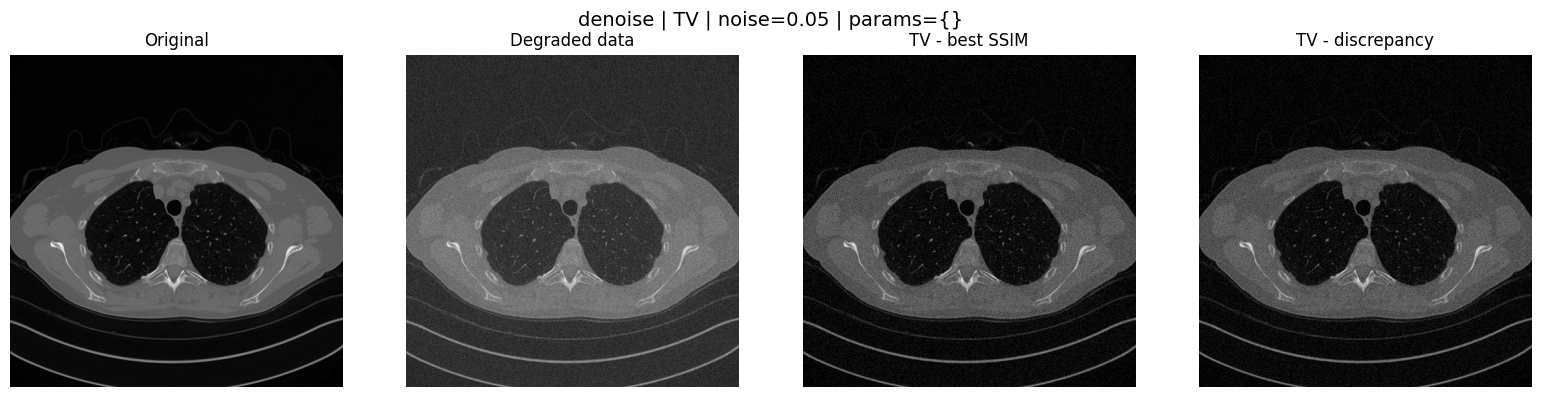

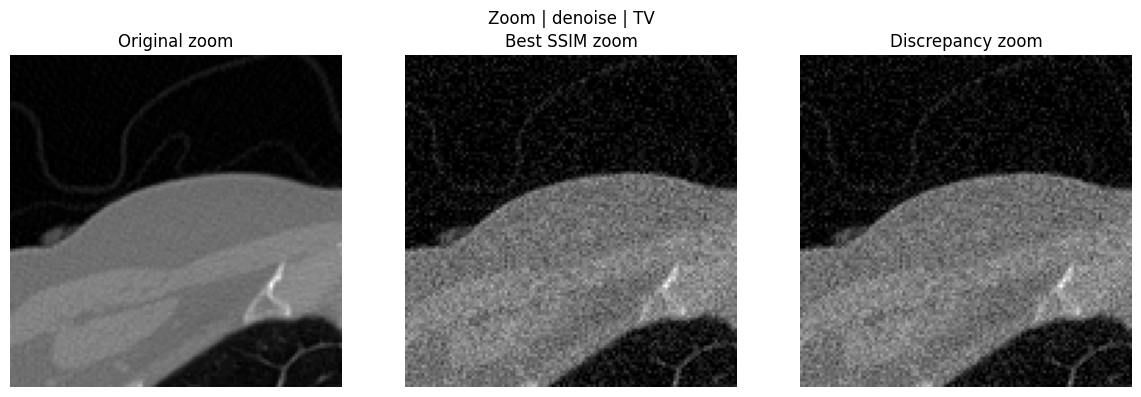

,task,method,noise_level,operator_params,lambda,residual,PSNR,SSIM,RE,target,distance_from_target
0,denoise,TV,0.05,{},0.0005,10.318276,27.003378,0.490624,0.198591,25.6,15.281724


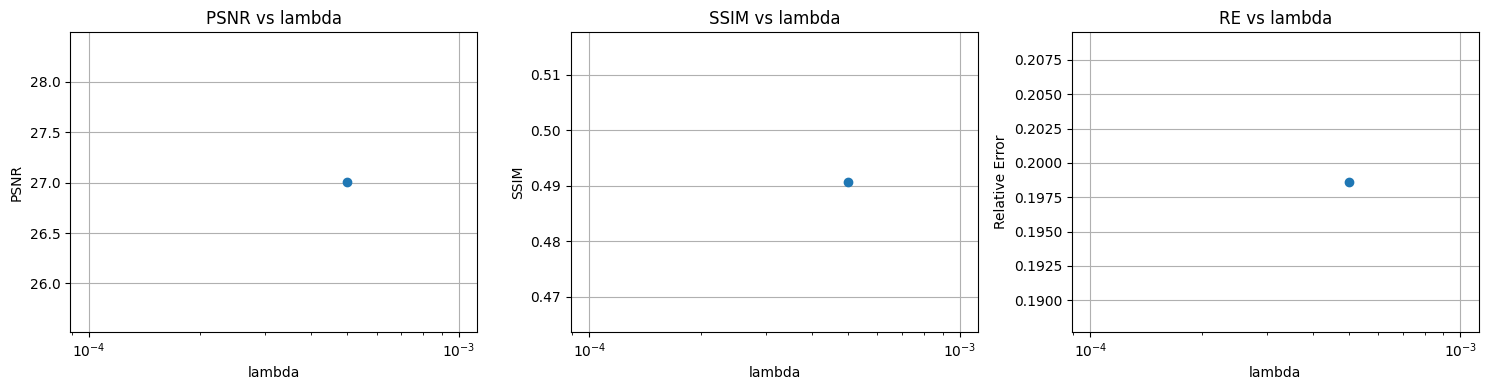

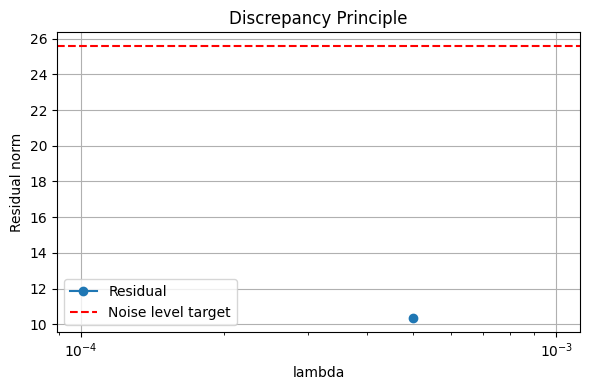

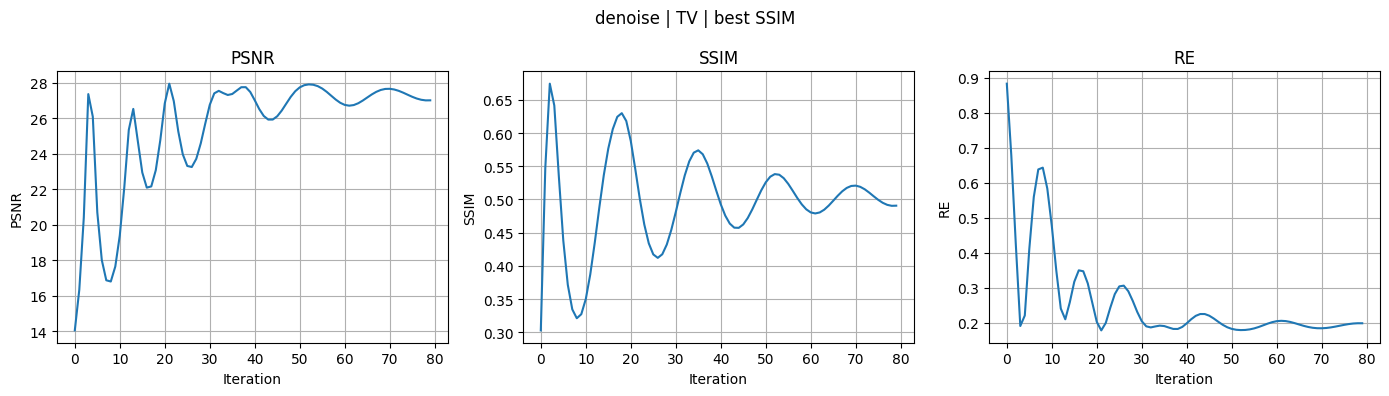

In [ ]:
# =========================
# CELLA 5 - VISUALIZZAZIONI E TABELLE
# =========================

# Controllo che la Cella 4 sia stata eseguita
required_names = [
    "x_true",
    "y_delta",
    "x_best_metric",
    "x_best_discrepancy",
    "lambda_table",
    "task_name",
    "method",
    "noise_level",
    "operator_params",
    "metric_for_best_lambda",
    "info_best_metric",
]

for name in required_names:
    if name not in globals():
        raise RuntimeError(f"Manca '{name}'. Devi prima eseguire la Cella 4.")


# =========================
# 1. IMMAGINI COMPLETE
# =========================

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(tensor_to_numpy(normalize(x_true)), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(tensor_to_numpy(normalize(y_delta)), cmap="gray")
plt.title("Degraded data")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(tensor_to_numpy(normalize(x_best_metric)), cmap="gray")
plt.title(f"{method} - best {metric_for_best_lambda}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(tensor_to_numpy(normalize(x_best_discrepancy)), cmap="gray")
plt.title(f"{method} - discrepancy")
plt.axis("off")

plt.suptitle(
    f"{task_name} | {method} | noise={noise_level} | params={operator_params}",
    fontsize=14
)

plt.tight_layout()
plt.show()


# =========================
# 2. ZOOM SU UNA REGIONE
# =========================

# Puoi cambiare questi valori se vuoi zoomare un'altra zona
x1, x2 = 100, 220
y1, y2 = 100, 220

original_zoom = tensor_to_numpy(normalize(x_true))[y1:y2, x1:x2]
best_metric_zoom = tensor_to_numpy(normalize(x_best_metric))[y1:y2, x1:x2]
discrepancy_zoom = tensor_to_numpy(normalize(x_best_discrepancy))[y1:y2, x1:x2]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_zoom, cmap="gray")
plt.title("Original zoom")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(best_metric_zoom, cmap="gray")
plt.title(f"Best {metric_for_best_lambda} zoom")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(discrepancy_zoom, cmap="gray")
plt.title("Discrepancy zoom")
plt.axis("off")

plt.suptitle(f"Zoom | {task_name} | {method}")
plt.tight_layout()
plt.show()


# =========================
# 3. TABELLA LAMBDA E METRICHE
# =========================

display(lambda_table)


# =========================
# 4. METRICHE AL VARIARE DI LAMBDA
# =========================

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.semilogx(lambda_table["lambda"], lambda_table["PSNR"], marker="o")
plt.xlabel("lambda")
plt.ylabel("PSNR")
plt.title("PSNR vs lambda")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.semilogx(lambda_table["lambda"], lambda_table["SSIM"], marker="o")
plt.xlabel("lambda")
plt.ylabel("SSIM")
plt.title("SSIM vs lambda")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.semilogx(lambda_table["lambda"], lambda_table["RE"], marker="o")
plt.xlabel("lambda")
plt.ylabel("Relative Error")
plt.title("RE vs lambda")
plt.grid(True)

plt.tight_layout()
plt.show()


# =========================
# 5. DISCREPANCY PRINCIPLE
# =========================

if "residual" in lambda_table.columns and "target" in lambda_table.columns:
    plt.figure(figsize=(6, 4))

    plt.semilogx(lambda_table["lambda"], lambda_table["residual"], marker="o", label="Residual")
    plt.axhline(lambda_table["target"].iloc[0], color="red", linestyle="--", label="Noise level target")

    plt.xlabel("lambda")
    plt.ylabel("Residual norm")
    plt.title("Discrepancy Principle")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# =========================
# 6. METRICHE RISPETTO ALLE ITERAZIONI
# =========================

def to_plot_array(values):
    clean_values = []

    for v in values:
        if torch.is_tensor(v):
            clean_values.append(float(v.detach().cpu()))
        else:
            clean_values.append(float(v))

    return clean_values


available_metrics = []

for metric_name in ["PSNR", "SSIM", "RE"]:
    if metric_name in info_best_metric:
        available_metrics.append(metric_name)

if len(available_metrics) == 0:
    print("No iteration metrics found in info.")
    print("Available keys:", info_best_metric.keys())
else:
    plt.figure(figsize=(14, 4))

    for i, metric_name in enumerate(available_metrics, start=1):
        plt.subplot(1, len(available_metrics), i)

        metric_values = to_plot_array(info_best_metric[metric_name])
        plt.plot(metric_values)

        plt.xlabel("Iteration")
        plt.ylabel(metric_name)
        plt.title(metric_name)
        plt.grid(True)

    plt.suptitle(f"{task_name} | {method} | best {metric_for_best_lambda}")
    plt.tight_layout()
    plt.show()